# AQI Predictor

This project predicts the AQI for the next 3 days in Karachi, Lahore, Faisalabad, Islamabad and Peshawar. Pollutants come from OpenWeather and weather comes from Open-Meteo. The features are stored in Hopsworks and the forecast is shown on a Streamlit dashboard.

## 00 — Setup

I will set up the constants used in the rest of the notebook: the five cities, the API endpoints and the EPA breakpoint table that turns pollutant readings into an AQI number.

In [31]:
import os
import pathlib
import time
import math
import tempfile
from datetime import datetime,timedelta,timezone
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hopsworks
from dotenv import load_dotenv
from tenacity import retry,stop_after_attempt,wait_exponential

load_dotenv()
OPENWEATHER_KEY = os.getenv("OPENWEATHER_API_KEY")
HOPSWORKS_KEY = os.getenv("HOPSWORKS_API_KEY")
HOPSWORKS_PROJECT = os.getenv("HOPSWORKS_PROJECT")

data_dir = pathlib.Path("data")
fig_dir = pathlib.Path("outputs/figures")
data_dir.mkdir(parents=True,exist_ok=True)
fig_dir.mkdir(parents=True,exist_ok=True)

sns.set_theme(style="whitegrid")

### Cities

I will use the city centre coordinates for the five cities. Both APIs take a lat and lon so the same dictionary works for both.

In [2]:
CITIES = {
    "Karachi":(24.86,67.01),
    "Lahore":(31.55,74.35),
    "Faisalabad":(31.41,73.07),
    "Islamabad":(33.72,73.06),
    "Peshawar":(34.01,71.57),
}

### API Endpoints

OpenWeather only sells historical weather on a paid plan so I will take the pollutants from OpenWeather and the weather from Open-Meteo which gives the ERA5 archive for free and without a key. Open-Meteo documents a lag of a few days on the archive endpoint so I have kept the forecast endpoint here as a fallback and will confirm at Step 1 whether the hourly pipeline actually needs it.

In [3]:
POLLUTION_URL = "http://api.openweathermap.org/data/2.5/air_pollution"
POLLUTION_HISTORY_URL = "http://api.openweathermap.org/data/2.5/air_pollution/history"
POLLUTION_FORECAST_URL = "http://api.openweathermap.org/data/2.5/air_pollution/forecast"

WEATHER_ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"
WEATHER_FORECAST_URL = "https://api.open-meteo.com/v1/forecast"

POLLUTANTS = ["pm2_5","pm10","o3","no2","so2","co","no","nh3"]

WEATHER_VARS = [
    "temperature_2m","relative_humidity_2m","dew_point_2m","precipitation",
    "surface_pressure","wind_speed_10m","wind_direction_10m","cloud_cover",
]

### EPA Breakpoints

OpenWeather returns its own AQI but it is only an integer from 1 to 5 which is too coarse to regress on. So I will compute the US EPA AQI instead, the 0 to 500 scale that aqicn and most public dashboards show.

The EPA gives a breakpoint table for each pollutant. Each row maps a concentration range to an AQI range and the AQI is found by interpolating between the two. Each pollutant is also averaged over a set number of hours before the lookup and the four gases have to be converted from µg/m³ first, so I will keep those here too.

In [4]:
# conc low, conc high, aqi low, aqi high
BREAKPOINTS = {
    # pm2_5 is the 2024 revised table
    "pm2_5":[
        (0.0,9.0,0,50),(9.1,35.4,51,100),(35.5,55.4,101,150),
        (55.5,125.4,151,200),(125.5,225.4,201,300),(225.5,325.4,301,500),
    ],
    "pm10":[
        (0,54,0,50),(55,154,51,100),(155,254,101,150),
        (255,354,151,200),(355,424,201,300),(425,604,301,500),
    ],
    "o3":[
        (0.000,0.054,0,50),(0.055,0.070,51,100),(0.071,0.085,101,150),
        (0.086,0.105,151,200),(0.106,0.200,201,300),
    ],
    "co":[
        (0.0,4.4,0,50),(4.5,9.4,51,100),(9.5,12.4,101,150),
        (12.5,15.4,151,200),(15.5,30.4,201,300),(30.5,50.4,301,500),
    ],
    "so2":[
        (0,35,0,50),(36,75,51,100),(76,185,101,150),
        (186,304,151,200),(305,604,201,300),(605,1004,301,500),
    ],
    "no2":[
        (0,53,0,50),(54,100,51,100),(101,360,101,150),
        (361,649,151,200),(650,1249,201,300),(1250,2049,301,500),
    ],
}

AVERAGING_HOURS = {"pm2_5":24,"pm10":24,"o3":8,"co":8,"so2":1,"no2":1}

# o3 and co need ppm and the other two need ppb
MOLECULAR_WEIGHTS = {"o3":48.0,"co":28.01,"so2":64.06,"no2":46.01}

# epa truncates the concentration to this many decimals before the table lookup
TRUNCATE_DECIMALS = {"pm2_5":1,"pm10":0,"o3":3,"co":1,"so2":0,"no2":0}

### AQI Categories

The scale is split into six named bands. I will store each band with its upper limit so I can find the category for any AQI value.

In [5]:
AQI_CATEGORIES = [
    (50,"Good","green"),
    (100,"Moderate","gold"),
    (150,"Unhealthy for Sensitive Groups","orange"),
    (200,"Unhealthy","red"),
    (300,"Very Unhealthy","purple"),
    (500,"Hazardous","darkred"),
]

## 01 — Data Fetch

I will write fetch_pollution and fetch_weather and test both on Lahore over the last 7 days so I can check the shapes, units and timestamp alignment before pulling the full three year history.

Outputs:
- pollution_test — hourly pollutant components for Lahore, last 7 days
- weather_test — hourly weather variables for Lahore, last 7 days

### Setup

In [6]:
lat,lon = CITIES["Lahore"]

end = datetime.now(timezone.utc)
start = end - timedelta(days=7)

### Pollution

The history endpoint takes start and end as unix timestamps in UTC so I will convert the datetime objects before calling it.

In [7]:
@retry(stop=stop_after_attempt(3),wait=wait_exponential(min=2,max=10))
def fetch_pollution(lat,lon,start,end):
    r = requests.get(POLLUTION_HISTORY_URL,params={"lat":lat,"lon":lon,"start":int(start.timestamp()),"end":int(end.timestamp()),"appid":OPENWEATHER_KEY},timeout=30)
    r.raise_for_status()
    return r.json()

data = fetch_pollution(lat,lon,start,end)
rows = []
for item in data["list"]:
    row = item["components"]
    row["timestamp_utc"] = pd.to_datetime(item["dt"],unit="s",utc=True)
    rows.append(row)
pollution_test = pd.DataFrame(rows)
print(f"lahore pollution: {pollution_test.shape}")
pollution_test.head()

lahore pollution: (168, 9)


,co,no,no2,o3,so2,pm2_5,pm10,nh3,timestamp_utc
0,428.44,0.05,13.33,41.97,3.08,26.14,30.19,9.15,2026-07-21 14:00:00+00:00
1,481.62,0.00,13.56,45.03,3.26,32.02,36.28,9.57,2026-07-21 15:00:00+00:00
2,542.81,0.00,12.99,50.89,3.68,40.22,44.67,10.19,2026-07-21 16:00:00+00:00
3,604.56,0.00,11.46,60.58,4.52,51.57,56.17,11.23,2026-07-21 17:00:00+00:00
4,657.20,0.00,9.54,71.64,5.79,64.41,68.99,12.14,2026-07-21 18:00:00+00:00


### Weather

I will pull the same window from the weather archive.

In [8]:
@retry(stop=stop_after_attempt(3),wait=wait_exponential(min=2,max=10))
def fetch_weather(lat,lon,start,end):
    r = requests.get(WEATHER_ARCHIVE_URL,params={"latitude":lat,"longitude":lon,"start_date":start.strftime("%Y-%m-%d"),"end_date":end.strftime("%Y-%m-%d"),"hourly":",".join(WEATHER_VARS),"timezone":"UTC"},timeout=30)
    r.raise_for_status()
    return r.json()

data = fetch_weather(lat,lon,start,end)
weather_test = pd.DataFrame(data["hourly"])
weather_test["time"] = pd.to_datetime(weather_test["time"],utc=True)
print(f"lahore weather: {weather_test.shape}")
weather_test.head()

lahore weather: (192, 9)


,time,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,cloud_cover
0,2026-07-21 00:00:00+00:00,26.9,92,25.5,1.9,975.8,11.5,112,99
1,2026-07-21 01:00:00+00:00,27.0,90,25.2,0.0,976.1,5.6,107,100
2,2026-07-21 02:00:00+00:00,27.1,91,25.5,0.4,976.8,10.6,69,100
3,2026-07-21 03:00:00+00:00,26.7,92,25.3,3.7,977.6,10.5,87,100
4,2026-07-21 04:00:00+00:00,27.7,94,26.7,10.5,978.1,8.4,118,100


## 02 — EPA AQI

I will average each pollutant over the window the EPA requires, convert the four gases into the units the breakpoint table expects and interpolate the table to get an AQI value and the pollutant that produced it.

Outputs:
- aqi and dominant_pollutant for the most recent hour in pollution_test

### Averaging

pm2_5 and pm10 use a 24 hour rolling average, ozone and carbon monoxide use 8 hours and sulfur dioxide and nitrogen dioxide use 1 hour. I will average each pollutant over its own window from the tail of pollution_test.

In [9]:
latest = {}
for pollutant in AVERAGING_HOURS:
    window = AVERAGING_HOURS[pollutant]
    latest[pollutant] = pollution_test[pollutant].tail(window).mean()

### AQI

The gases in latest are still in µg/m³ so I will convert them with their molecular weight first. The EPA table only defines AQI at specific truncated concentrations so I will truncate each converted value to the decimal place EPA uses before looking it up, otherwise a value that falls between two rows has no defined AQI. Each row of the table maps a concentration range onto an AQI range and I will interpolate inside whichever row the concentration falls in, then take the pollutant with the highest sub index as the overall AQI.

In [10]:
def convert_units(conc,pollutant):
    if pollutant not in MOLECULAR_WEIGHTS:
        return conc
    ppb = conc * 24.45 / MOLECULAR_WEIGHTS[pollutant]
    if pollutant in ("o3","co"):
        return ppb / 1000
    return ppb

def truncate(conc,pollutant):
    factor = 10 ** TRUNCATE_DECIMALS[pollutant]
    return math.floor(conc*factor) / factor

def calc_aqi(conc,pollutant):
    for bp_lo,bp_hi,aqi_lo,aqi_hi in BREAKPOINTS[pollutant]:
        if bp_lo <= conc <= bp_hi:
            return (aqi_hi-aqi_lo) / (bp_hi-bp_lo) * (conc-bp_lo) + aqi_lo
    return 500

def compute_aqi(concentrations):
    sub_indices = {}
    for pollutant,conc in concentrations.items():
        converted = convert_units(conc,pollutant)
        truncated = truncate(converted,pollutant)
        sub_indices[pollutant] = calc_aqi(truncated,pollutant)
    dominant_pollutant = max(sub_indices,key=sub_indices.get)
    aqi = round(sub_indices[dominant_pollutant])
    return aqi,dominant_pollutant

aqi,dominant_pollutant = compute_aqi(latest)
print(f"lahore aqi: {aqi} and dominant pollutant {dominant_pollutant}")

lahore aqi: 109 and dominant pollutant pm2_5


## 03 — Backfill

I will pull 3 years of hourly pollution and weather data for all 5 cities and save each of them.

Outputs:
- data/pollution_raw.parquet — hourly pollutant components for all 5 cities, 3 years
- data/weather_raw.parquet — hourly weather variables for all 5 cities, 3 years

### Setup

In [11]:
BACKFILL_END = datetime.now(timezone.utc)
BACKFILL_START = BACKFILL_END - timedelta(days=365*3)

### Pollution

The history endpoint only covers about a month at a time so I will chunk each city into 30 day windows with a short sleep between requests.

In [12]:
pollution_rows = []
for city,(lat,lon) in CITIES.items():
    chunk_start = BACKFILL_START
    while chunk_start < BACKFILL_END:
        chunk_end = min(chunk_start+timedelta(days=30),BACKFILL_END)
        data = fetch_pollution(lat,lon,chunk_start,chunk_end)
        for item in data["list"]:
            row = item["components"]
            row["timestamp_utc"] = pd.to_datetime(item["dt"],unit="s",utc=True)
            row["city"] = city
            pollution_rows.append(row)
        chunk_start = chunk_end
        time.sleep(1)

pollution_raw = pd.DataFrame(pollution_rows)
print(f"pollution rows: {len(pollution_raw)}")

pollution rows: 127992


### Weather

Open-Meteo returns the full three years in one call so I will fetch each city without chunking.

In [13]:
weather_frames = []
for city,(lat,lon) in CITIES.items():
    data = fetch_weather(lat,lon,BACKFILL_START,BACKFILL_END)
    df = pd.DataFrame(data["hourly"])
    df["city"] = city
    weather_frames.append(df)

weather_raw = pd.concat(weather_frames,ignore_index=True)
weather_raw["time"] = pd.to_datetime(weather_raw["time"],utc=True)
print(f"weather rows: {len(weather_raw)}")

weather rows: 131520


### Saving

In [14]:
pollution_raw.to_parquet(data_dir/"pollution_raw.parquet",index=False)
weather_raw.to_parquet(data_dir/"weather_raw.parquet",index=False)
print("saved in data/pollution_raw.parquet and data/weather_raw.parquet")

saved in data/pollution_raw.parquet and data/weather_raw.parquet


## 04 — Cleaning

I will merge pollution_raw and weather_raw into one table, drop any duplicate rows, reindex each city onto a complete hourly range and interpolate the short gaps left over from the backfill.

Outputs:
- data/hourly_clean.parquet — merged, deduplicated and gap filled hourly data for all 5 cities

### Loading

In [11]:
pollution_raw = pd.read_parquet(data_dir/"pollution_raw.parquet")
weather_raw = pd.read_parquet(data_dir/"weather_raw.parquet")

### Merging

The two datasets use different names for the timestamp column and can both hold duplicate rows from the chunked backfill so I will align the column name, drop duplicates and merge on city and timestamp_utc.

In [12]:
pollution_raw = pollution_raw.drop_duplicates(subset=["city","timestamp_utc"])
weather_raw = weather_raw.rename(columns={"time":"timestamp_utc"}).drop_duplicates(subset=["city","timestamp_utc"])

hourly = pd.merge(pollution_raw,weather_raw,on=["city","timestamp_utc"],how="outer")
print(f"merged rows: {len(hourly)}")

merged rows: 131520


### Reindexing

Each city should have one row for every hour in its range so I will reindex every city onto a complete hourly grid and interpolate gaps of up to 3 hours, leaving longer gaps as missing so they stay visible.

In [13]:
frames = []
for city in CITIES:
    sub = hourly[hourly["city"]==city].drop(columns="city").set_index("timestamp_utc").sort_index()
    full_range = pd.date_range(sub.index.min(),sub.index.max(),freq="h")
    sub = sub.reindex(full_range).interpolate(limit=3)
    sub["city"] = city
    frames.append(sub)

hourly = pd.concat(frames).rename_axis("timestamp_utc").reset_index()
print(f"rows: {len(hourly)} and still missing: {hourly.isna().sum().sum()}")

rows: 131520 and still missing: 25536


### Outlier Review

Lahore genuinely hits PM2.5 above 300 in winter smog so I will not clip high values. I will just look at the max pm2_5 per city to confirm nothing looks like a sensor error.

In [14]:
hourly.groupby("city")["pm2_5"].max()

city
Faisalabad     882.39
Islamabad      517.16
Karachi        967.96
Lahore        1308.81
Peshawar      1162.13
Name: pm2_5, dtype: float64

### Saving

In [15]:
hourly.to_parquet(data_dir/"hourly_clean.parquet",index=False)
print("saved in data/hourly_clean.parquet")

saved in data/hourly_clean.parquet


## 05 — EDA

I will compute an hourly aqi from the cleaned data and use it to look at daily, weekly and seasonal patterns, compare the five cities, check what correlates with pollution and confirm how much data is still missing after cleaning.

Outputs:
- outputs/figures/05a_diurnal_aqi.png — mean aqi by hour of day per city
- outputs/figures/05b_weekly_monthly_aqi.png — mean aqi by day of week and by month per city
- outputs/figures/05c_smog_season.png — mean aqi in the oct to feb smog season against the rest of the year
- outputs/figures/05d_city_comparison.png — aqi distribution per city
- outputs/figures/05e_correlation.png — pollutant correlation matrix
- outputs/figures/05g_missing_data.png — missing values per column per city

### Setup

In [16]:
hourly = pd.read_parquet(data_dir/"hourly_clean.parquet")
hourly["timestamp_pkt"] = hourly["timestamp_utc"] + pd.Timedelta(hours=5)

PALETTE = dict(zip(CITIES,sns.color_palette("tab10",n_colors=len(CITIES))))
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

### Hourly AQI

I will roll each pollutant over its EPA averaging window per city and then loop over the rows to get an aqi and a category for each hour. Rows where a pollutant is still missing are left blank.

In [17]:
rolled = hourly.copy()
for city in CITIES:
    mask = rolled["city"]==city
    for pollutant,window in AVERAGING_HOURS.items():
        rolled.loc[mask,pollutant] = rolled.loc[mask,pollutant].rolling(window,min_periods=window).mean()

aqi_col = []
dominant_col = []
for row in rolled[list(AVERAGING_HOURS)].itertuples(index=False):
    values = row._asdict()
    if any(pd.isna(v) for v in values.values()):
        aqi_col.append(np.nan)
        dominant_col.append(None)
    else:
        aqi,dominant = compute_aqi(values)
        aqi_col.append(aqi)
        dominant_col.append(dominant)

hourly["aqi"] = aqi_col
hourly["dominant_pollutant"] = dominant_col

hourly["category"] = None
for upper,name,color in AQI_CATEGORIES:
    hourly.loc[(hourly["aqi"]<=upper) & hourly["category"].isna(),"category"] = name

print(f"rows with aqi: {hourly['aqi'].notna().sum()}")

rows with aqi: 125752


### Diurnal Cycle

I will average aqi by hour of day in Pakistan time for each city to see when pollution peaks during the day.

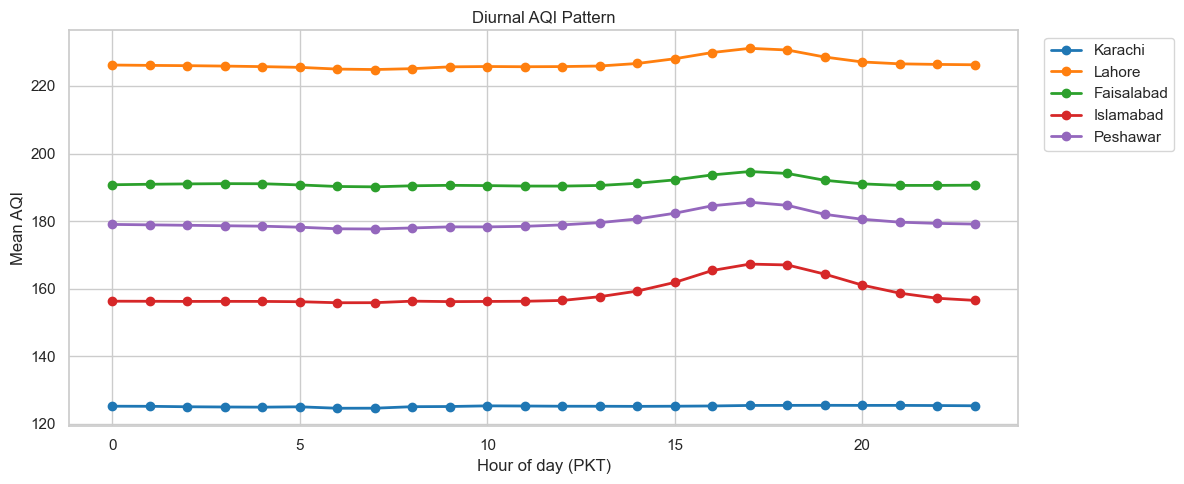

In [18]:
hourly["hour_pkt"] = hourly["timestamp_pkt"].dt.hour
diurnal = hourly.groupby(["city","hour_pkt"])["aqi"].mean().reset_index()

fig,ax = plt.subplots(figsize=(12,5))
for city in CITIES:
    sub = diurnal[diurnal["city"]==city].sort_values("hour_pkt")
    ax.plot(sub["hour_pkt"],sub["aqi"],marker="o",linewidth=2,label=city,color=PALETTE[city])

ax.set_xlabel("Hour of day (PKT)")
ax.set_ylabel("Mean AQI")
ax.set_title("Diurnal AQI Pattern")
ax.legend(loc="upper left",bbox_to_anchor=(1.02,1))
plt.tight_layout()
fig.savefig(fig_dir/"05a_diurnal_aqi.png",dpi=300,bbox_inches="tight")

### Weekly and Seasonal

I will average aqi by day of week and by month in Pakistan time to see the weekly traffic pattern and the yearly smog cycle.

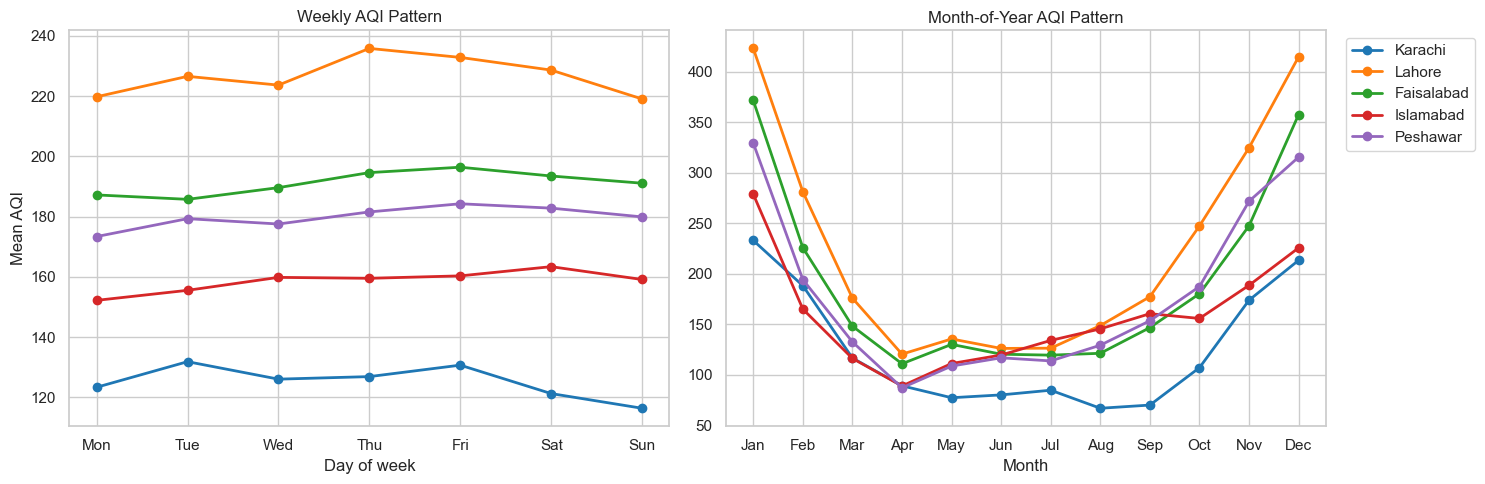

In [19]:
hourly["dow"] = hourly["timestamp_pkt"].dt.dayofweek
hourly["month"] = hourly["timestamp_pkt"].dt.month

weekly = hourly.groupby(["city","dow"])["aqi"].mean().reset_index()
monthly = hourly.groupby(["city","month"])["aqi"].mean().reset_index()

fig,axes = plt.subplots(1,2,figsize=(15,5))
for city in CITIES:
    sub = weekly[weekly["city"]==city].sort_values("dow")
    axes[0].plot(sub["dow"],sub["aqi"],marker="o",linewidth=2,label=city,color=PALETTE[city])
    sub = monthly[monthly["city"]==city].sort_values("month")
    axes[1].plot(sub["month"],sub["aqi"],marker="o",linewidth=2,label=city,color=PALETTE[city])

axes[0].set_xticks(range(7))
axes[0].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
axes[0].set_xlabel("Day of week")
axes[0].set_ylabel("Mean AQI")
axes[0].set_title("Weekly AQI Pattern")

axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(MONTH_NAMES)
axes[1].set_xlabel("Month")
axes[1].set_title("Month-of-Year AQI Pattern")
axes[1].legend(loc="upper left",bbox_to_anchor=(1.02,1))

plt.tight_layout()
fig.savefig(fig_dir/"05b_weekly_monthly_aqi.png",dpi=300,bbox_inches="tight")

### Smog Season

Pakistan's smog season runs October to February so I will mark those months and compare the average aqi inside and outside the season for each city.

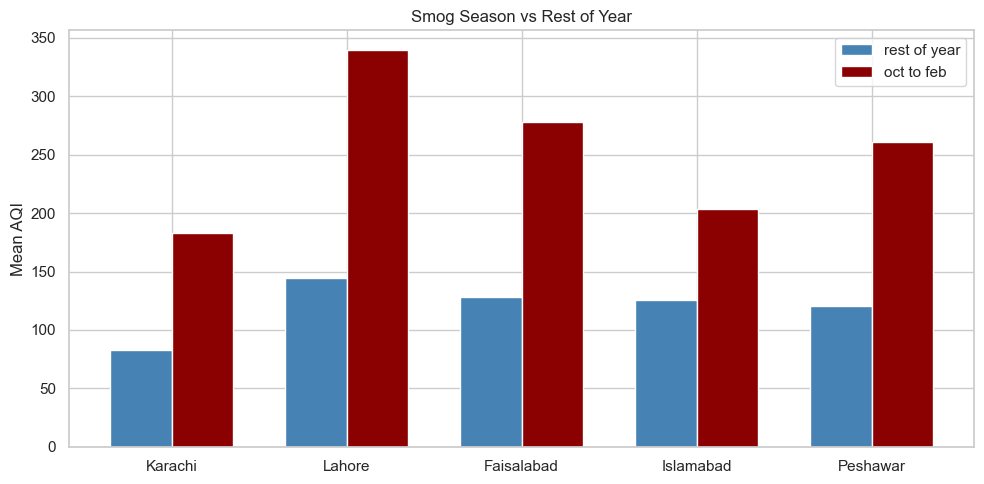

In [20]:
hourly["is_smog_season"] = hourly["month"].isin([10,11,12,1,2])
smog_mean = hourly[hourly["is_smog_season"]].groupby("city")["aqi"].mean()
rest_mean = hourly[~hourly["is_smog_season"]].groupby("city")["aqi"].mean()

fig,ax = plt.subplots(figsize=(10,5))
x = np.arange(len(CITIES))
width = 0.35
ax.bar(x-width/2,rest_mean[list(CITIES)],width,label="rest of year",color="steelblue")
ax.bar(x+width/2,smog_mean[list(CITIES)],width,label="oct to feb",color="darkred")
ax.set_xticks(x)
ax.set_xticklabels(list(CITIES))
ax.set_ylabel("Mean AQI")
ax.set_title("Smog Season vs Rest of Year")
ax.legend()
plt.tight_layout()
fig.savefig(fig_dir/"05c_smog_season.png",dpi=300,bbox_inches="tight")

### City Comparison

I will compare the full aqi distribution across cities with a boxplot so I can see both the typical level and the spread for each one.

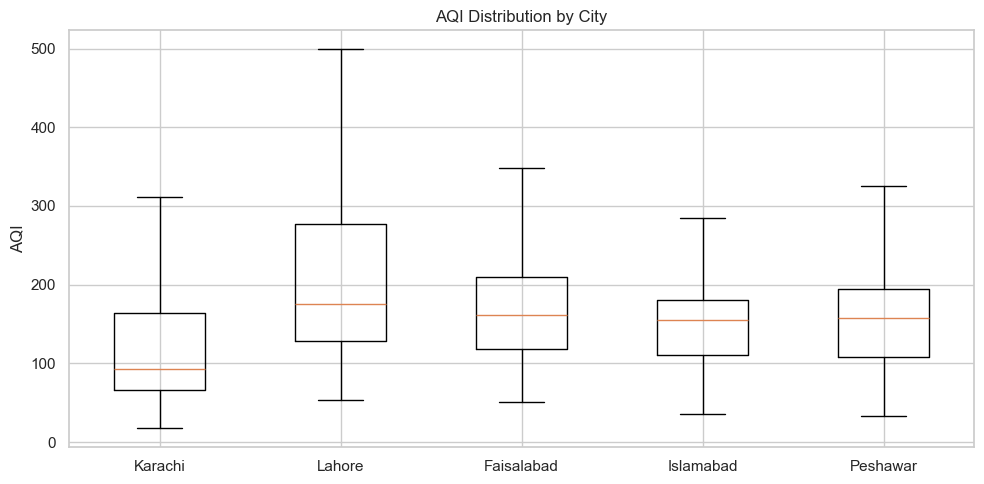

In [21]:
data_by_city = [hourly[hourly["city"]==city]["aqi"].dropna() for city in CITIES]

fig,ax = plt.subplots(figsize=(10,5))
ax.boxplot(data_by_city,tick_labels=list(CITIES),showfliers=False)
ax.set_ylabel("AQI")
ax.set_title("AQI Distribution by City")
plt.tight_layout()
fig.savefig(fig_dir/"05d_city_comparison.png",dpi=300,bbox_inches="tight")

### Correlation

I will look at how the 8 pollutants correlate with each other and with the overall aqi across all cities combined.

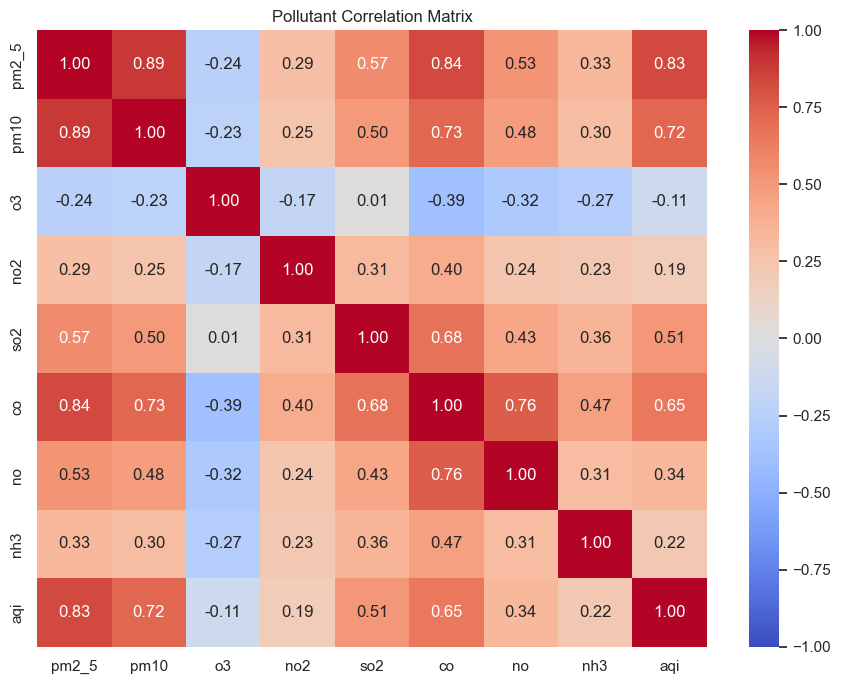

In [22]:
corr = hourly[POLLUTANTS+["aqi"]].corr()

fig,ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",vmin=-1,vmax=1,ax=ax)
ax.set_title("Pollutant Correlation Matrix")
plt.tight_layout()
fig.savefig(fig_dir/"05e_correlation.png",dpi=300,bbox_inches="tight")

### Missing Data

Interpolation in the cleaning step only fills gaps of up to 3 hours so I will count what is still missing per city.

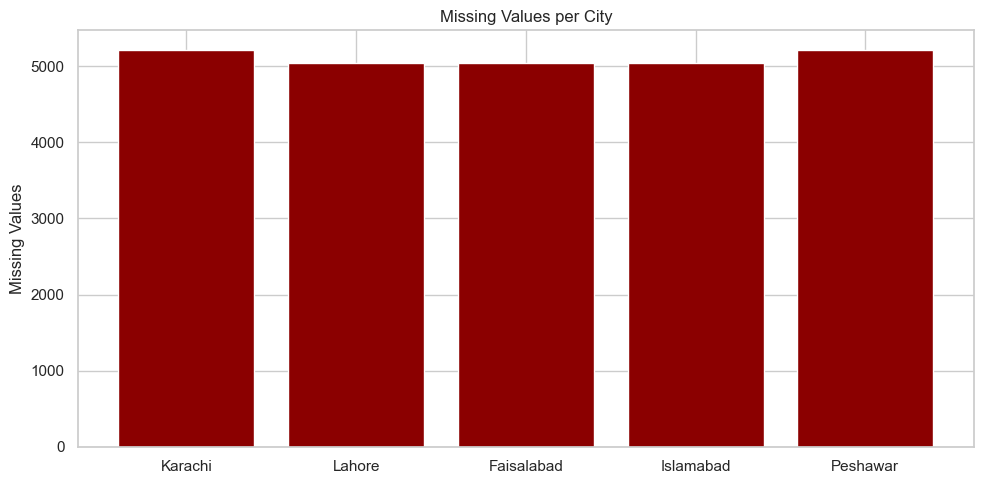

In [23]:
missing_counts = []
for city in CITIES:
    sub = hourly[hourly["city"]==city]
    missing_counts.append(sub[POLLUTANTS+WEATHER_VARS].isna().sum().sum())

fig,ax = plt.subplots(figsize=(10,5))
ax.bar(list(CITIES),missing_counts,color="darkred")
ax.set_ylabel("Missing Values")
ax.set_title("Missing Values per City")
plt.tight_layout()
fig.savefig(fig_dir/"05g_missing_data.png",dpi=300,bbox_inches="tight")

## 06 — Feature Engineering

I will build the hourly feature table with epa_aqi and cyclical time encodings and then aggregate it into a daily table with lags, rolling stats and the three day ahead targets. The daily table also carries the next three days of actual weather as the known future features since a real forecast is not available during backfill.

Outputs:
- data/hourly_features.parquet — hourly pollutants, weather, epa aqi and cyclical time features
- data/daily_features.parquet — daily aggregates, lags, rolling stats and the three targets aqi_d1, aqi_d2 and aqi_d3

### Setup

In [24]:
hourly = pd.read_parquet(data_dir/"hourly_clean.parquet")
hourly["timestamp_pkt"] = hourly["timestamp_utc"] + pd.Timedelta(hours=5)

### Hourly AQI

I will roll each pollutant over its EPA averaging window per city again on the fresh load and call compute_aqi to get epa_aqi and dominant_pollutant for every hour.

In [25]:
rolled = hourly.copy()
for city in CITIES:
    mask = rolled["city"]==city
    for pollutant,window in AVERAGING_HOURS.items():
        rolled.loc[mask,pollutant] = rolled.loc[mask,pollutant].rolling(window,min_periods=window).mean()

aqi_col = []
dominant_col = []
for row in rolled[list(AVERAGING_HOURS)].itertuples(index=False):
    values = row._asdict()
    if any(pd.isna(v) for v in values.values()):
        aqi_col.append(np.nan)
        dominant_col.append(None)
    else:
        aqi,dominant = compute_aqi(values)
        aqi_col.append(aqi)
        dominant_col.append(dominant)

hourly["epa_aqi"] = aqi_col
hourly["dominant_pollutant"] = dominant_col

print(f"rows with epa_aqi: {hourly['epa_aqi'].notna().sum()}")

rows with epa_aqi: 125752


### Cyclical Time Features

Hour, day of week and month all repeat so a plain integer tells the model 23 and 0 are far apart when they are one hour apart. I will encode each one as a sine and cosine pair instead and do the same for wind direction in degrees.

In [26]:
def cyclical_encode(values,period):
    radians = 2*np.pi*values/period
    return np.sin(radians),np.cos(radians)

hourly["hour"] = hourly["timestamp_pkt"].dt.hour
hourly["dow"] = hourly["timestamp_pkt"].dt.dayofweek
hourly["month"] = hourly["timestamp_pkt"].dt.month

hourly["hour_sin"],hourly["hour_cos"] = cyclical_encode(hourly["hour"],24)
hourly["dow_sin"],hourly["dow_cos"] = cyclical_encode(hourly["dow"],7)
hourly["month_sin"],hourly["month_cos"] = cyclical_encode(hourly["month"],12)
hourly["wind_dir_sin"],hourly["wind_dir_cos"] = cyclical_encode(hourly["wind_direction_10m"],360)

### Daily Aggregation

I will aggregate the hourly table to one row per city per day and take the mean and max of each pollutant, the mean of each weather variable and the sum of precipitation.

In [27]:
hourly["date"] = hourly["timestamp_pkt"].dt.date

daily = hourly.groupby(["city","date"]).agg(
    pm2_5_mean=("pm2_5","mean"),pm2_5_max=("pm2_5","max"),
    pm10_mean=("pm10","mean"),pm10_max=("pm10","max"),
    o3_mean=("o3","mean"),o3_max=("o3","max"),
    no2_mean=("no2","mean"),no2_max=("no2","max"),
    so2_mean=("so2","mean"),so2_max=("so2","max"),
    co_mean=("co","mean"),co_max=("co","max"),
    no_mean=("no","mean"),no_max=("no","max"),
    nh3_mean=("nh3","mean"),nh3_max=("nh3","max"),
    temp_mean=("temperature_2m","mean"),
    humidity_mean=("relative_humidity_2m","mean"),
    wind_mean=("wind_speed_10m","mean"),
    pressure_mean=("surface_pressure","mean"),
    cloud_mean=("cloud_cover","mean"),
    precip_sum=("precipitation","sum"),
    aqi=("epa_aqi","mean"),
).reset_index()

daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values(["city","date"]).reset_index(drop=True)
print(f"daily rows: {len(daily)}")

daily rows: 5485


### Lags, Rolling Stats and Future Values

Aqi_lag, the rolling stats, the future weather columns and the targets all need to shift within one city at a time so I will loop over each city and compute them on the masked slice. This keeps one city's dates from ever crossing into another city's window.

In [28]:
for city in CITIES:
    mask = daily["city"]==city

    for lag in [1,2,3,7]:
        daily.loc[mask,f"aqi_lag_{lag}"] = daily.loc[mask,"aqi"].shift(lag)
    for lag in [1,2,3]:
        daily.loc[mask,f"pm25_lag_{lag}"] = daily.loc[mask,"pm2_5_mean"].shift(lag)

    daily.loc[mask,"aqi_roll_mean_3"] = daily.loc[mask,"aqi"].rolling(3).mean()
    daily.loc[mask,"aqi_roll_mean_7"] = daily.loc[mask,"aqi"].rolling(7).mean()
    daily.loc[mask,"aqi_roll_std_7"] = daily.loc[mask,"aqi"].rolling(7).std()
    daily.loc[mask,"aqi_change_rate"] = daily.loc[mask,"aqi"].pct_change()

    for h in [1,2,3]:
        daily.loc[mask,f"fc_temp_d{h}"] = daily.loc[mask,"temp_mean"].shift(-h)
        daily.loc[mask,f"fc_wind_d{h}"] = daily.loc[mask,"wind_mean"].shift(-h)
        daily.loc[mask,f"fc_precip_d{h}"] = daily.loc[mask,"precip_sum"].shift(-h)
        daily.loc[mask,f"fc_humidity_d{h}"] = daily.loc[mask,"humidity_mean"].shift(-h)
        daily.loc[mask,f"aqi_d{h}"] = daily.loc[mask,"aqi"].shift(-h)

### Ratio and Calendar Features

pm25_pm10_ratio only needs the same row so it does not go in the loop above. I will also add day of week, month and day of year as sine and cosine pairs, plus a weekend flag and a one hot column per city.

In [29]:
daily["pm25_pm10_ratio"] = daily["pm2_5_mean"] / daily["pm10_mean"]

daily["dow"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month
daily["doy"] = daily["date"].dt.dayofyear
daily["doy_sin"],daily["doy_cos"] = cyclical_encode(daily["doy"],365)
daily["is_weekend"] = daily["dow"].isin([5,6]).astype(int)

city_dummies = pd.get_dummies(daily["city"],prefix="city").astype(int)
daily = pd.concat([daily,city_dummies],axis=1)

print(f"daily columns: {daily.shape[1]}")

daily columns: 63


### Saving

In [30]:
hourly.to_parquet(data_dir/"hourly_features.parquet",index=False)
daily.to_parquet(data_dir/"daily_features.parquet",index=False)
print("saved in data/hourly_features.parquet and data/daily_features.parquet")

saved in data/hourly_features.parquet and data/daily_features.parquet


## 07 — Hopsworks

I will create the aqi_hourly and aqi_daily feature groups in Hopsworks and insert the full backfill into both and then build a feature view over aqi_daily and materialize a training dataset for the three day ahead targets.

Outputs:
- aqi_hourly feature group — hourly pollutant and weather features per city
- aqi_daily feature group — daily aggregates, lags and the three day ahead aqi targets
- aqi_daily_view feature view — training dataset for the three day ahead models

### Setup

In [32]:
# windows has no tmp folder by default so the external client needs somewhere to write session certs
project = hopsworks.login(host="eu-west.cloud.hopsworks.ai",api_key_value=HOPSWORKS_KEY,project=HOPSWORKS_PROJECT,cert_folder=tempfile.gettempdir())
fs = project.get_feature_store()

2026-07-31 18:30:00,899 INFO: Initializing external client


2026-07-31 18:30:00,907 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-07-31 18:30:06,489 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41113


### Feature Groups

City and timestamp together are the primary key for aqi_hourly and city and date are the primary key for aqi_daily so every row is uniquely identified and Hopsworks can track freshness from the event time column.

In [33]:
hourly = pd.read_parquet(data_dir/"hourly_features.parquet")
daily = pd.read_parquet(data_dir/"daily_features.parquet")

hourly_fg = fs.get_or_create_feature_group(
    name="aqi_hourly",
    version=1,
    description="hourly pollutant and weather features per city",
    primary_key=["city","timestamp_utc"],
    event_time="timestamp_utc",
    time_travel_format="HUDI",
    statistics_config=False,
)
hourly_fg.insert(hourly,wait=True)

daily_fg = fs.get_or_create_feature_group(
    name="aqi_daily",
    version=1,
    description="daily aggregates, lags, rolling stats and the three day ahead aqi targets",
    primary_key=["city","date"],
    event_time="date",
    time_travel_format="HUDI",
    statistics_config=False,
)
daily_fg.insert(daily,wait=True)

Uploading Dataframe: 0.00% |          | Rows 0/131520 | Elapsed Time: 00:00 | Remaining Time: ?

Uploading Dataframe: 0.00% |          | Rows 1/131520 | Elapsed Time: 00:01 | Remaining Time: 55:36:44

Uploading Dataframe: 1.38% |▏         | Rows 1815/131520 | Elapsed Time: 00:02 | Remaining Time: 02:28

Uploading Dataframe: 2.19% |▏         | Rows 2876/131520 | Elapsed Time: 00:03 | Remaining Time: 02:21

Uploading Dataframe: 2.96% |▎         | Rows 3891/131520 | Elapsed Time: 00:04 | Remaining Time: 02:17

...

2026-07-31 18:34:36,969 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED


2026-07-31 18:36:10,080 INFO: Waiting for execution to finish. Current state: AGGREGATING_LOGS. Final status: SUCCEEDED


2026-07-31 18:36:10,334 INFO: Waiting for log aggregation to finish.


2026-07-31 18:36:19,350 INFO: Execution finished successfully.


(Job('aqi_daily_1_offline_fg_materialization', 'SPARK'), None)

### Feature View

I will build a feature view over aqi_daily selecting every column and marking aqi_d1, aqi_d2 and aqi_d3 as labels so a model can pull a ready made feature and target split straight from the materialized training dataset.

In [34]:
query = daily_fg.select_all()

feature_view = fs.get_or_create_feature_view(
    name="aqi_daily_view",
    version=1,
    query=query,
    labels=["aqi_d1","aqi_d2","aqi_d3"],
)
feature_view.create_training_data(description="daily features for the three day ahead aqi models")

Finished: Materializing data to Hopsworks, using Hopsworks Feature Query Service (1.47s) 


(2,
 b'/Projects/internship_project_mohid/internship_project_mohid_Training_Datasets/aqi_daily_view_1_2/aqi_daily_view_1/part-00000.parquet')

### Round Trip

I will read both feature groups back from Hopsworks and compare their shape and timestamp range against the local parquet files to confirm everything went well.

In [35]:
hourly_back = fs.get_feature_group(name="aqi_hourly",version=1).read()
daily_back = fs.get_feature_group(name="aqi_daily",version=1).read()

print(f"hourly {hourly_back.shape} | {hourly_back['timestamp_utc'].min()} to {hourly_back['timestamp_utc'].max()}")
print(f"daily {daily_back.shape} | {daily_back['date'].min()} to {daily_back['date'].max()}")

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (12.24s) 


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.60s) 
hourly (131520, 33) | 2023-07-28 00:00:00+00:00 to 2026-07-27 23:00:00+00:00
daily (5485, 63) | 2023-07-28 00:00:00+00:00 to 2026-07-28 00:00:00+00:00
